In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# MNIST 데이터를 불러온다.
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 차원 변환 후, 테스트셋과 학습셋으로 나눈다.
X_train = X_train.reshape(X_train.shape[0], 784).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 784).astype('float32') / 255

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

총 784개의 속성이 있고 열 개의 클래스가 있다. 따라서 다음과 같이 딥러닝 프레임을 만들 수 있다.

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()
model.add(Dense(512, input_dim=784, activation='relu'))
model.add(Dense(10, activation='softmax'))

딥러닝 실행 환경을 위해 오차 함수로 categorical_crossentropy, 최적화 함수로 adam을 사용한다.

In [3]:
model.compile(loss='categorical_crossentropy', optimizer='adam',
              metrics=['accuracy'])

모델의 최적화 단계에서는 학습을 자동 중단하게끔 설정한다.  
열 번 이상 모델 성능이 향상되지 않으면 자동으로 학습을 중단한다.

In [4]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# 모델 최적화를 위한 설정 구간이다.
modelpath = "./MNIST_MLP.hdf5"
checkpointer = ModelCheckpoint(filepath=modelpath, monitor='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

In [5]:
from pathlib import PureWindowsPath
# 모델을 실행한다.
history = model.fit(X_train, y_train, validation_split=0.25, epochs=30,
                    batch_size=200, verbose=0, callbacks=[early_stopping_callback, checkpointer])

# 테스트 정화도를 출력한다.
print("\n Test Accuracy: %.4f" % model.evaluate(X_test, y_test)[1])


Epoch 1: val_loss improved from inf to 0.18010, saving model to ./MNIST_MLP.hdf5


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(



Epoch 2: val_loss improved from 0.18010 to 0.13605, saving model to ./MNIST_MLP.hdf5

Epoch 3: val_loss improved from 0.13605 to 0.11354, saving model to ./MNIST_MLP.hdf5

Epoch 4: val_loss improved from 0.11354 to 0.09741, saving model to ./MNIST_MLP.hdf5

Epoch 5: val_loss improved from 0.09741 to 0.09405, saving model to ./MNIST_MLP.hdf5

Epoch 6: val_loss improved from 0.09405 to 0.08491, saving model to ./MNIST_MLP.hdf5

Epoch 7: val_loss improved from 0.08491 to 0.08170, saving model to ./MNIST_MLP.hdf5

Epoch 8: val_loss did not improve from 0.08170

Epoch 9: val_loss did not improve from 0.08170

Epoch 10: val_loss did not improve from 0.08170

Epoch 11: val_loss improved from 0.08170 to 0.08050, saving model to ./MNIST_MLP.hdf5

Epoch 12: val_loss improved from 0.08050 to 0.08021, saving model to ./MNIST_MLP.hdf5

Epoch 13: val_loss did not improve from 0.08021

Epoch 14: val_loss improved from 0.08021 to 0.07916, saving model to ./MNIST_MLP.hdf5

Epoch 15: val_loss did not i

학습셋의 오차는 1에서 학습셋의 정확도를 뺀 값이다. 좀 더 세밀한 변화를 볼 수 있게 학습셋의 오차와 테스트셋의 오차를 그래프 하나로 나타낸다.

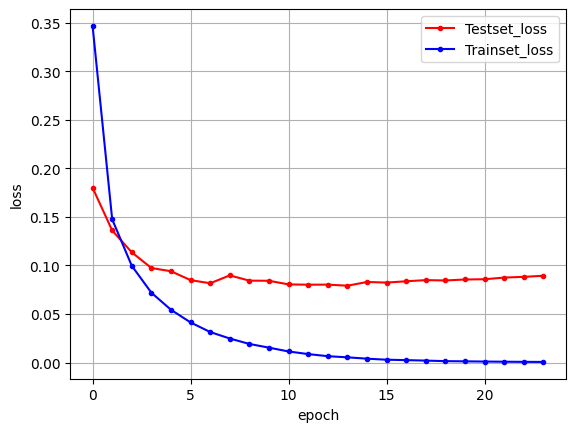

In [6]:
import matplotlib.pyplot as plt
import numpy as np

y_vloss = history.history['val_loss']

# 학습셋의 오차
y_loss = history.history['loss']

# 그래프로 표현한다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시한다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

실습| MNIST 손글씨 인식하기: 기본 프레임

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 512)               401920    
                                                                 
 dense_3 (Dense)             (None, 10)                5130      
                                                                 
Total params: 407050 (1.55 MB)
Trainable params: 407050 (1.55 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

Epoch 1: val_loss improved from inf to 0.19210, saving model to ./MNIST_MLP.hdf5

Epoch 2: val_loss improved from 0.19210 to 0.14076, saving model to ./MNIST_MLP.hdf5

Epoch 3: val_loss improved from 0.14076 to 0.11785, saving model to ./MNIST_MLP.hdf5

Epoch 4: val_loss improved from 0.11785 to 0.09819, saving model to ./MNIST_MLP.hdf5

Epoch 5: val_loss improved from 0.09819 to 0.09448, saving model to ./MNI

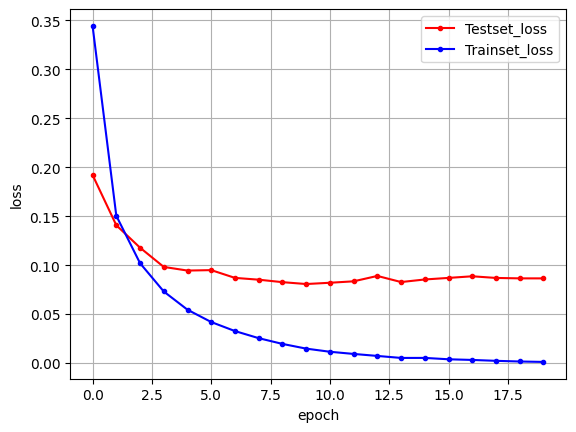

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

import matplotlib.pyplot as plt
import numpy as np
import os

# MNIST 데이터를 불러온다.
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 차원 변환 후, 테스트셋과 학습셋으로 나눈다.
X_train = X_train.reshape(X_train.shape[0], 784).astype('float32') / 255
X_test = X_test.reshape(X_test.shape[0], 784).astype('float32') / 255

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# 모델 구조를 설정한다.
model = Sequential()
model.add(Dense(512, input_dim=784, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

# 모델 실행 환경을 설정한다.
model.compile(loss='categorical_crossentropy', optimizer='adam',
              metrics=['accuracy'])

# 모델 최적화를 위한 설정 구간이다.
modelpath = "./MNIST_MLP.hdf5"
checkpointer = ModelCheckpoint(filepath=modelpath, model='val_loss',
                               verbose=1, save_best_only=True)
early_stopping_callback = EarlyStopping(monitor='val_loss', patience=10)

# 모델을 실행한다.
history = model.fit(X_train, y_train, validation_split=0.25, epochs=30,
                    batch_size=200, verbose=0, callbacks=[early_stopping_callback,
                                                          checkpointer])

# 테스트 정확도를 출력한다.
print("\n Test Accuracy: %.4f" % (model.evaluate(X_test, y_test)[1]))

# 검증셋과 학습셋의 오차를 저장한다.
y_vloss = history.history['val_loss']
y_loss = history.history['loss']

# 그래프로 표현해본다.
x_len = np.arange(len(y_loss))
plt.plot(x_len, y_vloss, marker='.', c='red', label='Testset_loss')
plt.plot(x_len, y_loss, marker='.', c='blue', label='Trainset_loss')

# 그래프에 그리드를 주고 레이블을 표시해본다.
plt.legend(loc='upper right')
plt.grid()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()